---
numbering: false
---

# 7.2. Multiple Linear Regression

In [Chapter 7.1](./01-regression-using-linear-algebra.ipynb), we learned how to use our knowledge of spans and projections to recast the problem of finding optimal model parameters for the simple linear regression model, $h(x_i) = w_0 + w_1 x_i$. Along the way, we defined new characters, most importantly, the design matrix 


$$\color{#3d81f6} X = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_n \end{bmatrix}$$

Here, we'll look at how and why to extend $\color{#3d81f6} X$ to include multiple input features, in what's called **multiple linear regression**.

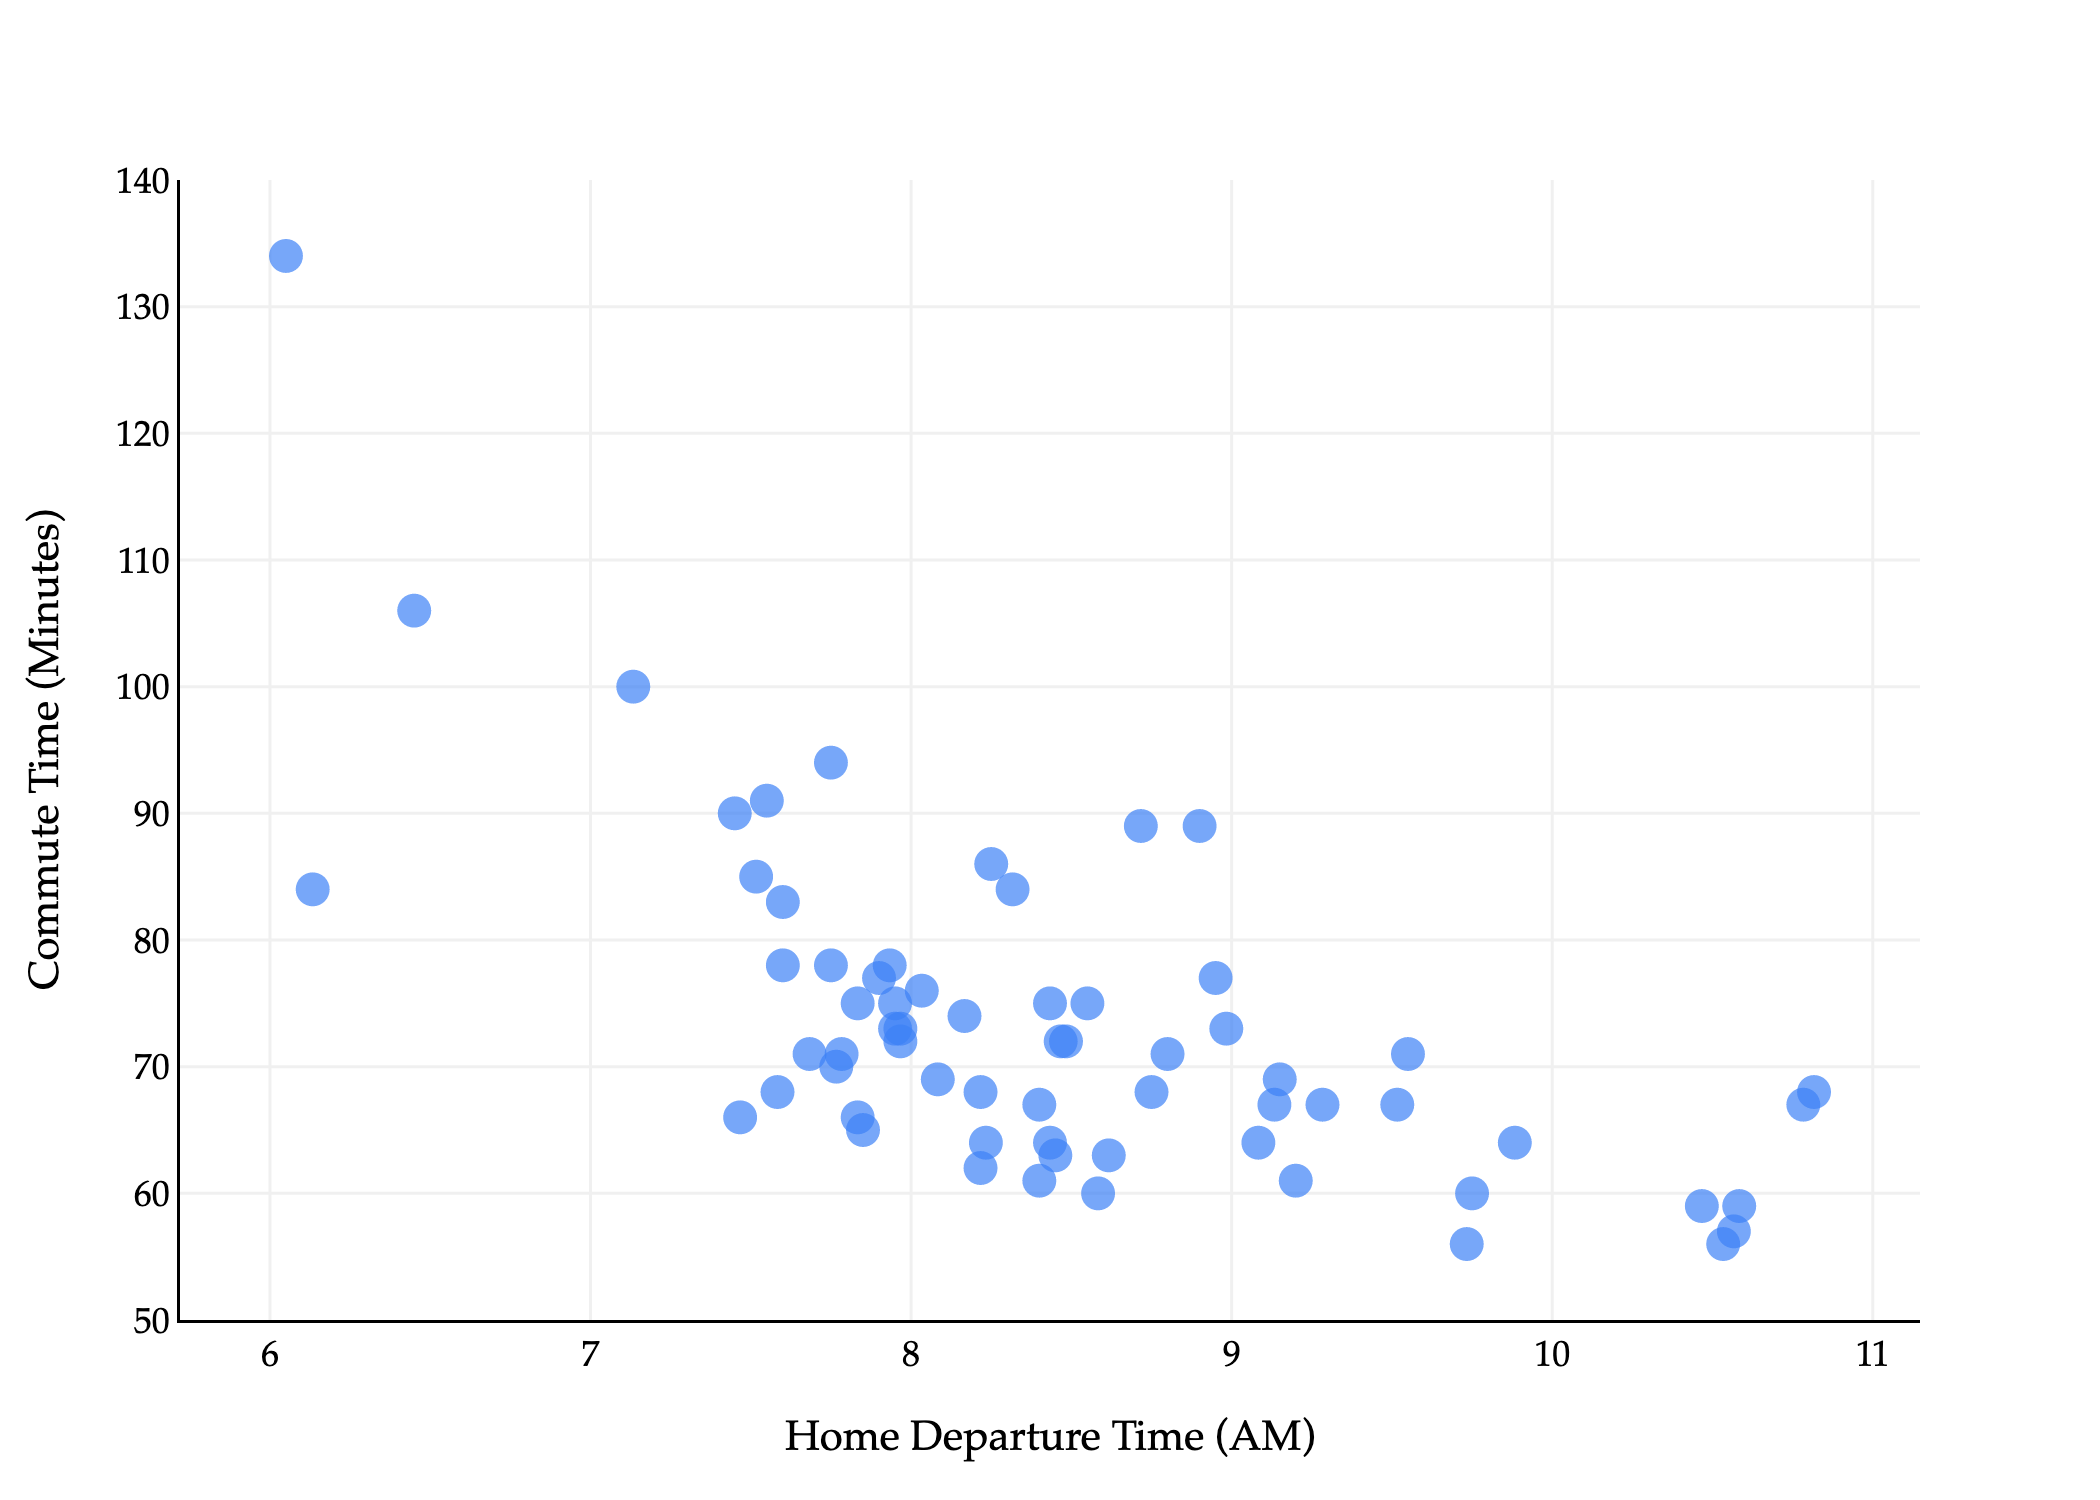

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv('data/commute-times.csv')

fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)
fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)
fig.show(renderer='png', scale=3)

---

## Incorporating Multiple Features

### Motivation

The commute times dataset that we were reintroduced to in [Chapter 7.1](./01-regression-using-linear-algebra.ipynb) has several columns in it, but we've only used one – `departure_hour` – as an input variable.

In [4]:
import pandas as pd
import numpy as np

commutes_full = pd.read_csv('data/commute-times.csv')
commutes_full['day_of_month'] = pd.to_datetime(df['date']).dt.day
# df[['departure_hour', 'day_of_month', 'minutes']].head()

In [5]:
commutes_full.head()

,date,day,home_departure_time,home_departure_mileage,work_arrival_time,work_arrival_mileage,comments_from_home_to_work,work_departure_time,work_departure_mileage,home_arrival_time,home_arrival_mileage,comments_from_work_to_home,minutes,departure_hour,mileage_to_work,minutes_to_home,work_departure_time_hr,mileage_to_home,day_of_month
0,5/15/2023,Mon,2023-05-15 10:49:00,15873.0,2023-05-15 11:57:00,15926.0,stopped for coffee,2023-05-15 17:10:00,15926.0,2023-05-15 18:22:00,15979.0,NaN,68.0,10.816667,53.0,72.0,17.166667,53.0,15
1,5/16/2023,Tue,2023-05-16 07:45:00,15979.0,2023-05-16 09:19:00,16033.0,stopped for gas by exit 10 of state route 16,NaN,NaN,NaN,NaN,NaN,94.0,7.750000,54.0,NaN,NaN,NaN,16
2,5/22/2023,Mon,2023-05-22 08:27:00,50407.0,2023-05-22 09:30:00,50461.0,NaN,2023-05-22 15:54:00,50461.0,2023-05-22 17:16:00,50515.0,NaN,63.0,8.450000,54.0,82.0,15.900000,54.0,22
3,5/23/2023,Tue,2023-05-23 07:08:00,50535.0,2023-05-23 08:48:00,50589.0,NaN,NaN,NaN,NaN,NaN,NaN,100.0,7.133333,54.0,NaN,NaN,NaN,23
4,5/30/2023,Tue,2023-05-30 09:09:00,50664.0,2023-05-30 10:18:00,50718.0,"South Gate did not open, drove around to North...",2023-05-30 17:07:00,50718.0,2023-05-30 18:23:00,50772.0,NaN,69.0,9.150000,54.0,76.0,17.116667,54.0,30


Let's take a look at a subset of them.

In [6]:
commutes_full[['departure_hour', 'day', 'day_of_month', 'minutes']].head()

,departure_hour,day,day_of_month,minutes
0,10.816667,Mon,15,68.0
1,7.750000,Tue,16,94.0
2,8.450000,Mon,22,63.0
3,7.133333,Tue,23,100.0
4,9.150000,Tue,30,69.0


For example, the first row above tells us that the first recorded commute was on a Monday, which was the 15th of that month.

Using `day` seems like it would be a good idea, since traffic patterns likely differ based on the day of the week. But, it's not clear how to use strings, like `'Tue'`, in a linear model. We'll address this in a moment. For now, suppose we'd like to fit a linear model that predicts commute time in `minutes` using **both** `departure_hour` and `day_of_month` ("dom" for short).

Such a hypothesis function is of the form

$$\underbrace{h(\text{departure hour}_i, \text{dom}_i)}_{= \text{pred. commute}_i} = w_0 + w_1 \cdot \text{departure hour}_i + w_2 \cdot \text{dom}_i$$

which is a **plane** in $\mathbb{R}^3$. Once we figure out how to find $w_0^*$, $w_1^*$, and $w_2^*$, we'll visualize the resulting plane, not to worry.

(To be crystal clear, the $\cdot$'s in the above equations refer to "regular" scalar multiplication, not the dot product. There are no vectors in the equation above.)

But, **how** do we find these three optimal model parameters? If we consult the modeling recipe, and choose squared loss, we need to find the values of $w_0^*$, $w_1^*$, and $w_2^*$ that minimize

$$R_\text{sq}(w_0, w_1, w_2) = \frac{1}{n} \sum_{i = 1}^n (y_i - \left( w_0 + w_1 \cdot \text{departure hour}_i + w_2 \cdot \text{dom}_i \right))^2$$

The solution is to use what we know about spans, projections, and the design matrix. The design matrix for this problem will have **3** columns: a column of 1's for the intercept, a column of `departure_hour` values, and a column of `dom` values.

\begin{align*}
{\color{#004d40} \vec p} &= \begin{bmatrix} w_0 + w_1 \cdot {\color{#3d81f6} \text{departure hour}_1} + w_2 \cdot {\color{#3d81f6} \text{dom}_1} \\ w_0 + w_1 \cdot {\color{#3d81f6} \text{departure hour}_2} + w_2 \cdot {\color{#3d81f6} \text{dom}_2} \\ \vdots \\ w_0 + w_1 \cdot {\color{#3d81f6} \text{departure hour}_n} + w_2 \cdot {\color{#3d81f6} \text{dom}_n}  \end{bmatrix}
\\ &= {\color{#3d81f6} \underbrace{\begin{bmatrix} 1 & \text{departure hour}_1 & \text{dom}_1 \\ 1 & \text{departure hour}_2 & \text{dom}_2 \\ \vdots & \vdots & \vdots \\ 1 & \text{departure hour}_n & \text{dom}_n \end{bmatrix}}_{X}} \underbrace{\begin{bmatrix} w_0 \\ w_1 \\ w_2 \end{bmatrix}}_{\vec w}
\end{align*}

To find $\vec w^*$, all we need to do is define the observation vector, $\color{orange} \vec y = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}$, and find the $\vec w^*$ that minimizes

$$R_\text{sq}(\vec w) = \frac{1}{n} \left\lVert {\color{orange} \vec y} - {\color{#3d81f6} X} \vec w \right\lVert^2$$

which is a solved problem at this point: it's the $\vec w^*$ that satisfies the normal equation, ${\color{#3d81f6} X^TX} \vec w^* = {\color{#3d81f6} X^T} \color{orange} \vec y$.

### Generalized Notation

Let me try and state this problem in slightly more general terms, where we have $d$ features rather than just 1 or 2.

As before, subscripts distinguish between **individuals (rows)** in our dataset, and we will try and use superscripts (in parentheses) to distinguish between **features (columns)**. Specifically, we'll use the notation $x_i^{(j)}$ to represent the $j$-th feature for the $i$-th individual. In the example above, $x_5^{(1)}$ is the departure hour for the 5th row in the dataset. Think of $x^{(1)}$, $x^{(2)}$, ... as new variable names, like new letters.

Consider the following example dataset.

In [7]:
commutes_full[['departure_hour', 'day_of_month', 'minutes']].head(3)

,departure_hour,day_of_month,minutes
0,10.816667,15,68.0
1,7.750000,16,94.0
2,8.450000,22,63.0


There are $n = 3$ rows, each of which has $d = 2$ features (`minutes` is **not** a feature, it's what we're trying to predict).

We can represent each row (day) with a **feature vector**, $\vec x_i = \begin{bmatrix} x_i^{(1)} \\ x_i^{(2)} \end{bmatrix}$. A feature vector contains all of the information we're using to make predictions for the $i$-th individual.

$$\vec x_1 = \begin{bmatrix} 10.816667 \\ 15 \end{bmatrix}, \qquad \vec x_2 = \begin{bmatrix} 7.75 \\ 16 \end{bmatrix}, \qquad \vec x_3 = \begin{bmatrix} 8.45 \\ 22 \end{bmatrix}$$

In general,

$$\vec x_i = \begin{bmatrix} x_i^{(1)} \\ x_i^{(2)} \\ \vdots \\ x_i^{(d)} \end{bmatrix}$$

Note that if our model has $d$ features, then there are $d+1$ parameters, $w_0$, $w_1$, $w_2$, ..., $w_d$. There is one parameter for each feature, **plus** one for the intercept. So, the generalized **multiple** linear regression model has a hypothesis function of the form

$$h(\vec x_i) = w_0 + w_1 x_i^{(1)} + w_2 x_i^{(2)} + \ldots + w_d x_i^{(d)}$$

It'd be great if we could express our hypothesis function $h$ as a dot product between a parameter vector $\vec w$ and a feature vector $\vec x_i$, but we can't: $\vec w$ has $d+1$ components while $\vec x_i$ has $d$ components.

To address this issue, we'll define the **augmented feature vector**, $\text{Aug}({\vec x_i})$, which is the vector obtained by adding a 1 to the front of feature vector $\vec x_i$ (much like the design matrix $\color{#3d81f6} X$ has a column of 1's).

$$\text{Aug}({\vec x_i}) = \begin{bmatrix} 1 \\ x_i^{(1)} \\ x_i^{(2)} \\ \vdots \\ x_i^{(d)} \end{bmatrix}$$

Then, the multiple linear regression model can be written as

$$\boxed{h(\vec x_i) = w_0 + w_1 x_i^{(1)} + w_2 x_i^{(2)} + \ldots + w_d x_i^{(d)} = \vec w \cdot \text{Aug}({\vec x_i})}$$

### The General Problem

Now we can finally state the problem of multiple linear regression in its most general form. Suppose we have $n$ data points, $\left({ \vec x_1}, {y_1}\right), \left({ \vec x_2}, {y_2}\right),  \ldots, \left({ \vec x_n}, {y_n}\right)$, where each $ \vec x_i$ is a feature vector of $d$ features:

$${\vec{x_i}} = \begin{bmatrix} 
{x^{(1)}_i} \\ {x^{(2)}_i} \\ \vdots \\ {x^{(d)}_i}
\end{bmatrix}$$	   

We'd like to find a good **linear** model,

$$h({\vec x_i}) = w_0 + w_1 { x_i^{(1)}} + w_2 { x_i^{(2)}} + \ldots + w_d { x_i^{(d)}} = \vec w \cdot \text{Aug}({ \vec x_i})$$

By **good**, we mean that we'd like to find optimal parameters $w_0^*$, $w_1^*$, ..., $w_d^*$ that minimize mean squared error:

$$\underbrace{\begin{align*} R_\text{sq}(\vec w) &= \frac{1}{n} \sum_{i = 1}^n (y_i - h(\vec x_i))^2 \\ &=
\frac{1}{n} \sum_{i = 1}^n \left( y_i - (w_0 + w_1 { x_i^{(1)}} + w_2 { x_i^{(2)}} + \ldots + w_d { x_i^{(d)}})\right)^2 
\\ &= \frac{1}{n} \sum_{i = 1}^n \left(y_i - \vec w \cdot \text{Aug}(\vec x_i) \right)^2 \\ &= \frac{1}{n} \lVert \vec y - X \vec w \rVert^2 \end{align*}}_\text{all equivalent ways of writing mean squared error!}$$

The solution is to define the $n \times (d + 1)$ design matrix $\color{#3d81f6} X$ and $n$-dimensional observation vector $\color{orange} \vec y$:

$${\color{#3d81f6} X=  \begin{bmatrix}  
{1} & { x^{(1)}_1} & { x^{(2)}_1} & \dots & { x^{(d)}_1} \\\\
{ 1} & { x^{(1)}_2} & { x^{(2)}_2} & \dots & { x^{(d)}_2} \\\\
\vdots & \vdots & \vdots  &  & \vdots \\\\
{ 1} & { x^{(1)}_n} & { x^{(2)}_n} & \dots & { x^{(d)}_n}
\end{bmatrix} = \begin{bmatrix} 
       \text{Aug}({\vec{x_1}})^T \\\\
       \text{Aug}({\vec{x_2}})^T \\\\
       \vdots \\\\
       \text{Aug}({\vec{x_n}})^T
   \end{bmatrix}}, \qquad \color{orange} { \vec y = \begin{bmatrix} { y_1} \\ { y_2} \\ \vdots \\ { y_n} \end{bmatrix}}$$

and to solve the normal equation to find the optimal parameter vector, $\vec{w}^*$:

$${\color{#3d81f6} X^TX} \vec w^* = {\color{#3d81f6} X^T} \color{orange} \vec y$$

The $\vec w^*$ that satisfies the equations above minimizes mean squared error, $R_\text{sq}(\vec w)$, so use this $\vec w^*$ to make predictions in $h(\vec x_i) = \vec w^* \cdot \text{Aug}(\vec x_i)$. Once you find that $\vec w^*$,

- ${\color{#004d40} \vec p} = {\color{#3d81f6} X} \vec w^*$ is a prediction vector of predicted $y$-values for the entire dataset. It is also the projection of $\color{orange} \vec y$ onto the span of the columns of $\color{#3d81f6} X$.
- $h(\vec x_i) = \vec w^* \cdot \text{Aug}(\vec x_i)$ is the predicted $y$-value for just the input $\vec x_i$.

### Using `sklearn`

Earlier in the course, we saw how to use `sklearn` to fit a simple linear regression model. Performing multiple linear regression is just as easy.

In [8]:
from sklearn.linear_model import LinearRegression

model_multiple = LinearRegression()
model_multiple.fit(X=commutes_full[['departure_hour', 'day_of_month']], y=commutes_full['minutes'])

LinearRegression()

After calling `fit`, we can access $\vec w^*$.

In [9]:
model_multiple.intercept_, model_multiple.coef_

(141.86402699471932, array([-8.2233821 ,  0.05615985]))

The outputs above tell us that the "best way" (according to squared loss) to make commute time predictions using a linear model is using:

$$\text{pred. commute}_i = 141.86 - 8.22 \cdot \text{departure hour}_i + 0.06 \cdot \text{day of month}_i$$

This is the **plane of best fit** given historical data; it is not a causal statement.

In [10]:
from plotly import graph_objects as go

XX, YY = np.mgrid[5:14:1, 0:31:1]
Z = model_multiple.intercept_ + model_multiple.coef_[0] * XX + model_multiple.coef_[1] * YY
plane = go.Surface(x=XX, y=YY, z=Z, colorscale='Reds')

fig = go.Figure(data=[plane])
fig.add_trace(go.Scatter3d(
    x=commutes_full['departure_hour'],
    y=commutes_full['day_of_month'],
    z=commutes_full['minutes'],
    mode='markers',
    marker={'color': '#3d81f6'}
))

fig.update_layout(
    scene=dict(
        xaxis_title='Departure Hour',
        yaxis_title='Day of Month',
        zaxis_title='Minutes',
        xaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            showbackground=True,
            zerolinecolor='#f0f0f0',
            title_font=dict(family="Palatino"),
            tickfont=dict(family="Palatino")
        ),
        yaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            showbackground=True,
            zerolinecolor='#f0f0f0',
            title_font=dict(family="Palatino"),
            tickfont=dict(family="Palatino")
        ),
        zaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            showbackground=True,
            zerolinecolor='#f0f0f0',
            title_font=dict(family="Palatino"),
            tickfont=dict(family="Palatino")
        ),
        dragmode='orbit'
    ),
    title={
        'text': 'Commute Time vs. Departure Hour and Day of Month',
        'font': dict(family="Palatino")
    },
    font=dict(family="Palatino"),
    width=1000,
    height=500,
    paper_bgcolor='white',
    plot_bgcolor='white'
)
fig.show()

Fit `LinearRegression` objects have a `predict` method, which can be used to predict commute times given a `departure_hour` and `day_of_month`.

In [11]:
# What if I leave at 9:15AM on the 26th of the month?
# To supress the warning below, we should convert X and y to numpy arrays before calling .fit.
model_multiple.predict([[9.25, 26]])

/Users/surajrampure/miniforge3/envs/pds/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([67.25789852])

In [12]:
model_multiple.predict(pd.DataFrame({'departure_hour': [9.25], 'day_of_month': [26]}))

array([67.25789852])

### Comparing Models

While it's not difficult to implement ourselves, `sklearn` has a built-in `mean_squared_error` function.

In [13]:
from sklearn.metrics import mean_squared_error
mean_squared_error(commutes_full['minutes'], model_multiple.predict(commutes_full[['departure_hour', 'day_of_month']]))

96.78730488437492

So, the mean squared error of our plane of best fit is 96.78 $\text{minutes}^2$.

Throughout this section, we'll fit various different models to the commute times dataset, and it'll be useful to keep track of their mean squared errors in one place. I'll do so in a Python dictionary. (I'm intentionally showing you more code than I typically have, so you have some sense of how to do this all yourself – I hope you don't mind!)

In [14]:
mse_dict = {}

# Multiple linear regression model.
mse_dict['departure_hour + day_of_month'] = mean_squared_error(commutes_full['minutes'], model_multiple.predict(commutes_full[['departure_hour', 'day_of_month']]))

# Simple linear regression model.
model_simple = LinearRegression()
model_simple.fit(X=commutes_full[['departure_hour']], y=commutes_full['minutes'])
mse_dict['departure_hour'] = mean_squared_error(commutes_full['minutes'], model_simple.predict(commutes_full[['departure_hour']]))

# Constant model.
model_constant = commutes_full['minutes'].mean()
mse_dict['constant'] = mean_squared_error(commutes_full['minutes'], np.ones(commutes_full.shape[0]) * model_constant)

mse_dict

{'departure_hour + day_of_month': 96.78730488437492,
 'departure_hour': 97.04687150819183,
 'constant': 167.535147928994}

As you can see, adding `day_of_month` **barely** reduced our model's mean squared error, which matches our intuition that knowing whether it's the 15th or 19th or 3rd of the month doesn't seem like it would be helpful in predicting commute time. The activity below has you think about _why_ the mean squared error still did decrease, and whether this is always the case.

:::{tip} Activity 1
:class: dropdown
Recall, **training data** is the data that we use to fit/train/create the model. **Test data** refers to any other data that we might use to evaluate the model's performance.

1. As we add more features, the mean squared error of a model's predictions **on the training data** will **never increase**. Why?
1. Could a model's mean squared error **on test data** increase as we add more features? When would it?
:::

---

## Feature Engineering

So far, we've limited ourselves to using `departure_hour` and `day_of_month`, two features that already came to us in the dataset. In practice, we'll often need to **engineer** features, which means creating new features from existing ones, or "transforming" raw data into good features. We might do this to improve model performance, for example, in case the relationship between the features and output variable isn't truly linear, or maybe even to enable the use of categorical features.

### Example: One Hot Encoding

Suppose we'd like to use the `day` column from `commutes_full` as a feature.

In [15]:
commutes_full[['departure_hour', 'day', 'day_of_month']].head()

,departure_hour,day,day_of_month
0,10.816667,Mon,15
1,7.750000,Tue,16
2,8.450000,Mon,22
3,7.133333,Tue,23
4,9.150000,Tue,30


One naive approach would be to convert each `day` value to a number, e.g. `"Mon"` is 1, `"Tue"` is 2, `"Wed"` is 3, etc. **The reason this is a bad idea** is that this approach implies that Monday is somehow "less than" Tuesday and should impact our model's predictions less than Tuesday (remember that this column will be multiplied by a parameter in order to make predictions). This is what's called an **ordinal encoding**, and these only make sense when the features have some inherent order that is meaningful to the prediction problem.

Instead, we'll perform **one hot encoding**, which turns a categorical feature into several binary features: one per unique value of the categorical feature.

<center><img src="./imgs/one-hot.png" width=300></center>

Since `day` has 5 unique values, we'll need to create 5 new binary features.

In [16]:
# pandas Series have a value_counts method, which describes the frequency of each unique value in the Series.
commutes_full['day'].value_counts()

day
Tue    25
Mon    20
Thu    15
Wed     3
Fri     2
Name: count, dtype: int64

Suppose we want to build a model that predicts `minutes` using `departure_hour`, `day_of_month`, **and** one hot encoded `day`. That model would have $1 + 1 + 5 = 7$ features, so its design matrix would have $7 + 1 = 8$ columns!

In [17]:
for_ohe = commutes_full[['departure_hour', 'day_of_month', 'day']].copy()
for val in commutes_full['day'].unique():
    for_ohe[f'day == {val}'] = (for_ohe['day'] == val).astype(int)
for_ohe['1'] = 1
X_for_ohe = for_ohe[['1', 'departure_hour', 'day_of_month', 'day == Mon', 'day == Tue', 'day == Wed', 'day == Thu', 'day == Fri']]
X_for_ohe.head()

,1,departure_hour,day_of_month,day == Mon,day == Tue,day == Wed,day == Thu,day == Fri
0,1,10.816667,15,1,0,0,0,0
1,1,7.750000,16,0,1,0,0,0
2,1,8.450000,22,1,0,0,0,0
3,1,7.133333,23,0,1,0,0,0
4,1,9.150000,30,0,1,0,0,0


The actual process of one hot encoding can be done efficiently using `sklearn.preprocessing.OneHotEncoder`. You'll see how to use this in a homework assignment.

**Note that while it looks like the `day == Wed`, `day == Thu`, and `day == Fri` columns are all 0's**, this is just because there were no Wednesday, Thursday, or Friday values **in the first five rows** of the dataset. Somewhere later on in the dataset, there were rows with Wednesday, Thursday, or Friday values, and so those columns have non-zero values later on. If there were never any Wednesday, Thursday, or Friday values, then we wouldn't make those columns in the first place (just like we never made a Saturday column, or a Zebra column, etc.).

**Question**: What is the rank of the design matrix, whose first five rows are shown above?

You might notice that among the 5 binary columns, in a particular row, **exactly** one of them is 1, and the other 4 are 0. This means that if we sum together the 5 binary columns, we'll get a column of 1's – which is already the first column in our design matrix!

This means that, by default, when we perform one hot encoding, the design matrix doesn't have full rank. This doesn't stop us from projecting $\color{orange} \vec y$ onto $\text{colsp}({\color{#3d81f6} X})$, but it does mean that there are infinitely many possible optimal parameters $\vec w^*$. Again, all of these would give us the same predictions and same mean squared error, but it's annoying to have to deal with this setting.

In [18]:
np.linalg.matrix_rank(X_for_ohe) # Not 8!

7

In [19]:
X_for_ohe['day == Mon'] + X_for_ohe['day == Tue'] + X_for_ohe['day == Wed'] + X_for_ohe['day == Thu'] + X_for_ohe['day == Fri']

0     1
1     1
2     1
3     1
4     1
     ..
60    1
61    1
62    1
63    1
64    1
Length: 65, dtype: int64

So, a common solution when performing one hot encoding is to **drop one of the binary columns**. This doesn't change the information conveyed by the other features, and doesn't change $\text{colsp}({\color{#3d81f6} X})$, which is what matters for the quality of the model's predictions. And intuitively, even if we don't have the value of `day == Fri`, we know it's Friday if `day == Mon`, `day == Tue`, `day == Wed`, and `day == Thu` are all 0.

Now that we've converted `day` to a numerical variable, we can use it as input in a regression model. Here's the model we'll try to fit:

$$\begin{align*}\text{pred. commute time}_i = w_0 &+ w_1 \cdot \text{departure hour}_i \\ &+ w_2 \cdot \text{day of month}_i \\ &+ w_3 \cdot \text{day$_i$ == Mon} \\ 
&+ w_4 \cdot \text{day$_i$ == Tue} \\ 
&+ w_5 \cdot \text{day$_i$ == Wed} \\ 
&+ w_6 \cdot \text{day$_i$ == Thu} \end{align*}$$

This model has 6 features (1 + 1 + 4) and hence 7 parameters. Its design matrix is $n \times 7$.

In [20]:
X_for_ohe = for_ohe[['1', 'departure_hour', 'day_of_month', 'day == Mon', 'day == Tue', 'day == Wed', 'day == Thu']]
X_for_ohe.head()

,1,departure_hour,day_of_month,day == Mon,day == Tue,day == Wed,day == Thu
0,1,10.816667,15,1,0,0,0
1,1,7.750000,16,0,1,0,0
2,1,8.450000,22,1,0,0,0
3,1,7.133333,23,0,1,0,0
4,1,9.150000,30,0,1,0,0


Notice that below, I've set `fit_intercept=False`, because I manually added a column of 1's to the design matrix, so I don't need `sklearn` to add another one.

In [21]:
model_with_ohe = LinearRegression(fit_intercept=False)
model_with_ohe.fit(X=X_for_ohe, y=commutes_full['minutes'])

LinearRegression(fit_intercept=False)

In [22]:
model_with_ohe.coef_

array([ 1.34043066e+02, -8.41714813e+00, -2.52657944e-02,  5.09024617e+00,
        1.63763100e+01,  5.11983892e+00,  1.14972088e+01])

So, our linear model to predict commute time given `departure_hour`, `day_of_month`, and `day` (Mon, Tue, Wed, or Thu) is:

$$\begin{align*}\text{pred. commute time}_i = 134 &- 8.42 \cdot \text{departure hour}_i \\ &- 0.03 \cdot \text{day of month}_i \\ 
&+ 5.09 \cdot \text{day$_i$ == Mon} \\ 
&+ 16.38 \cdot \text{day$_i$ == Tue} \\ 
&+ 5.12 \cdot \text{day$_i$ == Wed} \\ 
&+ 11.5 \cdot \text{day$_i$ == Thu} \end{align*}$$

While this model has 6 features, and thus requires 7 dimensions to graph, it's really a collection of **five parallel planes** in 3D, all with slightly different $z$-intercepts! Remember that $\text{day}_i == \text{Mon}$, $\text{day}_i == \text{Tue}$, etc. aren't all free variables: if one of them is 1, the others must be 0. There are 5 cases to consider, and each one corresponds to one of these 5 parallel planes. You're exploring this idea in Homework 7, Question 3.

If we do want to visualze the model in $\mathbb{R}^2$, we need to pick a single feature to place on the $x$-axis.

In [23]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df['departure_hour'], y=df['minutes'],
    mode='markers',
    name='Actual Data',
    marker=dict(color='#3d81f6', size=8)
))
fig.add_trace(go.Scatter(
    x=df['departure_hour'], y=model_with_ohe.predict(X_for_ohe),
    mode='markers',
    name='Predicted Commute Times',
    marker=dict(color='orange', size=8)
))

fig.update_layout(
    showlegend=True,
    title='',
    xaxis_title='Departure Hour',
    yaxis_title='Minutes',
    width=700,
    plot_bgcolor='white',
    font=dict(family='Palatino'),
    xaxis=dict(gridcolor='#f0f0f0'),
    yaxis=dict(gridcolor='#f0f0f0'),
)

Despite being a linear model, this model doesn't look like a straight line, since it's linear in terms of **all 6 features**, but when you project it into 2D, it no longer appears linear.

How does this new model compare to our previous models?

In [24]:
mse_dict['departure_hour + day_of_month + day'] = mean_squared_error(
    commutes_full['minutes'],
    model_with_ohe.predict(X_for_ohe)
)

mse_dict

{'departure_hour + day_of_month': 96.78730488437492,
 'departure_hour': 97.04687150819183,
 'constant': 167.535147928994,
 'departure_hour + day_of_month + day': 70.21791287461917}

Note that adding the day of the week decreased our model's mean squared error **significantly**: this one hot encoded model is our best yet.

:::{tip} Activity 2
:class: dropdown

Suppose we use the code below to build a multiple linear regression model to predict the width of a fish, given its height and weight.

```
model = LinearRegression()
model.fit(X, y)

# Used in the answer choices below.
ws = np.append(model.intercept_, model.coef_)
preds = model.predict(X)
squares = X.shape[0] * mean_squared_error(y, preds)
```

Assume that:
- $X$ and `X` refer to the **full rank** $n \times 3$ design matrix used to fit the model.
- $\vec y$ and `y` refer to the obdservation vector.
- $\vec w^*$ refers to the optimal parameter vector found by `sklearn`.

In **each column** of the grid below, **select all** mathematical expressions that have the same value as the expression provided in the column header. Some rows may end up empty, but every column should have at least one expression picked. Assume that $0$ and $\vec 0$ are the same for the purposes of this question.

$$
\begin{array}{|l|c|c|c|c|}
\hline
\text{}                & \texttt{preds}           & \texttt{ws}       & \texttt{squares}  & \texttt{np.sum(y - preds)} \\
\hline
0                      &                          &                   &                   &                             \\
\hline
\|\vec{y} - X\vec{w}^*\|^2  &                      &                   &     &                             \\
\hline
X^T X \vec{w}^* - X^T \vec{y}  &                   &                   &                   &                             \\
\hline
\vec{1}^T (\vec{y} - X\vec{w}^*) &                &                   &                   &   \\
\hline
(X^T X)^{-1} X^T \vec{y}    &                     &        &                   &                             \\
\hline
X (X^T X)^{-1} X^T \vec{y}  &      &                   &                   &                             \\
\hline
\end{array}
$$

:::{seealso} Solution
:class: dropdown

$$
\begin{array}{|l|c|c|c|c|}
\hline
\text{}                & \texttt{preds}           & \texttt{ws}       & \texttt{squares}  & \texttt{np.sum(y - preds)} \\
\hline
0                      &                          &                   &                   &           \times                  \\
\hline
\|\vec{y} - X\vec{w}^*\|^2  &                      &                   &  \times   &                             \\
\hline
X^T X \vec{w}^* - X^T \vec{y}  &                   &                   &                   &          \times                      \\
\hline
\vec{1}^T (\vec{y} - X\vec{w}^*) &                &                   &                   &  \times  \\
\hline
(X^T X)^{-1} X^T \vec{y}    &                     &   \times     &                   &                             \\
\hline
X (X^T X)^{-1} X^T \vec{y}  &   \times    &                   &                   &                             \\
\hline
\end{array}
$$

Let's look at each **column** one by one.
- `preds`, in math, is a vector of predicted values, $\vec p = X \vec w^*$. Since $X$'s columns are linearly independent, $\vec w^*$ is the unique vector $\vec w^* = (X^T X)^{-1} X^T \vec y$, and so $\vec p = X (X^T X)^{-1} X^T \vec y$.
- `ws` is $(X^T X)^{-1} X^T \vec y$, as discussed above.
- `squares` is the mean squared error of the predictions, multiplied by $n$ (i.e. it's the sum of squared errors). Mean squared error is $\frac{1}{n} \lVert \vec y - X \vec w^* \rVert^2$, so `squares` is $\lVert \vec y - X \vec w^* \rVert^2$.
- `np.sum(y - preds)` is the sum of the components in $\vec y - X \vec w^*$, which we know is **0**. This is because:
    - $X$ contains a column of 1's, and
    - the error vector $\vec e = \vec y - X \vec w^*$ must be orthogonal to each of $X$'s columns, so
    - $\vec e \cdot \begin{bmatrix} 1 \\ \vdots \\ 1 \end{bmatrix} = 0$, so
    - $e_1 + e_2 + \ldots + e_n = 0$.
    This was introduced in [Chapter 6.3](../06_linear_transformations_and_projections/03-projecting-onto-column-space.ipynb#example-orthogonality-with-the-columns-of-x) and revisited in [Chapter 7.1](./01-regression-using-linear-algebra.ipynb#errors-sum-to-0).

    So, any other expression on the left that is equal to 0 (or $\vec 0$) should be selected.
    - $0$, the first row, should be seleccted.
    - $X^TX \vec w^* - X^T \vec y$ is equal to $\vec 0$, since $\vec w^*$ satisfies the normal equations, $X^TX \vec w^* = X^T \vec y$.
    - $\vec 1^T (\vec y - X \vec w^*)$ is equal to 0, using the logic above.

:::

### Example: Numerical Transformations

Another common step in feature engineering is to produce new numerical features out of existing ones.

In [25]:
commutes_full[['departure_hour', 'day', 'day_of_month']].head()

,departure_hour,day,day_of_month
0,10.816667,Mon,15
1,7.750000,Tue,16
2,8.450000,Mon,22
3,7.133333,Tue,23
4,9.150000,Tue,30


As an example, I could fit a degree 2 polynomial model

$$h(x_i) = w_0 + w_1 x_i + w_2 x_i^2$$

by producing the design matrix

$$X = \begin{bmatrix} 1 & x_1 & x_1^2 \\ 1 & x_2 & x_2^2 \\ \vdots & \vdots & \vdots \\ 1 & x_n & x_n^2 \\  \end{bmatrix}$$

Below, we'll apply this thinking to the `departure_hour` feature. We'll create these features manually, though in homework assignments you'll see how to do this easily and more efficiently using `sklearn.preprocessing.PolynomialFeatures`.

In [26]:
X_for_quadratic = commutes_full[['departure_hour']].copy()
X_for_quadratic['departure_hour^2'] = X_for_quadratic['departure_hour'] ** 2

model_quadratic = LinearRegression()
model_quadratic.fit(X=X_for_quadratic, y=commutes_full['minutes'])
model_quadratic.intercept_, model_quadratic.coef_

(351.324480895268, array([-57.14500476,   2.8270457 ]))

This tells us that the best-fitting quadratic model is

$$h(x_i) = 351.32 - 57.14 \cdot \text{departure hour}_i + 2.83 \cdot (\text{departure hour}_i)^2.$$

which looks like:

In [51]:
quadratic_grid = pd.DataFrame({'departure_hour': np.linspace(5, 12, 200)})
quadratic_grid['departure_hour^2'] = quadratic_grid['departure_hour'] ** 2

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=commutes_full['departure_hour'],
    y=commutes_full['minutes'],
    mode='markers',
    name='Actual Data',
    marker=dict(color='#3d81f6', size=8)
))
fig.add_trace(go.Scatter(
    x=quadratic_grid['departure_hour'],
    y=model_quadratic.predict(quadratic_grid),
    mode='lines',
    name='Predicted Commute Times<br>(Degree 2 Model)',
    line=dict(color='orange', width=3)
))

fig.update_layout(
    showlegend=True,
    xaxis_title='Departure Hour',
    yaxis_title='Minutes',
    width=700,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Palatino'),
    xaxis=dict(gridcolor='#f0f0f0'),
    yaxis=dict(gridcolor='#f0f0f0')
)
fig.show()

**This is a linear model**, even though the features themselves are made up of non-linear functions.

If we treat $x_i$ and $x_i^2$ as two separate features, then each data point lives in $\mathbb{R}^3$ with coordinates

$$(x_i, x_i^2, y_i)$$

In that feature space, the model is

$$\text{predicted commute}_i = w_0 + w_1 \cdot \underbrace{\text{departure hour}_i}_{\text{feature 1}} + w_2 \cdot \underbrace{(\text{departure hour}_i)^2}_{\text{feature 2}}$$

so the predictions lie on a plane. It only looks curved when we project back down to the usual 2D plot of `departure_hour` versus `minutes`, because the points we draw must satisfy the relationship $x_i^2 = (x_i)^2$.

In [52]:
x_grid, x_sq_grid = np.mgrid[5:14:0.25, 25:196:4]
z_quadratic = (
    model_quadratic.intercept_
    + model_quadratic.coef_[0] * x_grid
    + model_quadratic.coef_[1] * x_sq_grid
)

quadratic_plane = go.Surface(
    x=x_grid,
    y=x_sq_grid,
    z=z_quadratic,
    colorscale='Oranges',
    showscale=False,
    opacity=0.8
)

fig = go.Figure(data=[quadratic_plane])
fig.add_trace(go.Scatter3d(
    x=X_for_quadratic['departure_hour'],
    y=X_for_quadratic['departure_hour^2'],
    z=commutes_full['minutes'],
    mode='markers',
    name='Actual Data',
    marker={'color': '#3d81f6', 'size': 4}
))

fig.update_layout(
    scene=dict(
        xaxis_title='Departure Hour',
        yaxis_title='Departure Hour^2',
        zaxis_title='Minutes',
        xaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            showbackground=True,
            zerolinecolor='#f0f0f0',
            title_font=dict(family='Palatino'),
            tickfont=dict(family='Palatino')
        ),
        yaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            showbackground=True,
            zerolinecolor='#f0f0f0',
            title_font=dict(family='Palatino'),
            tickfont=dict(family='Palatino')
        ),
        zaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            showbackground=True,
            zerolinecolor='#f0f0f0',
            title_font=dict(family='Palatino'),
            tickfont=dict(family='Palatino')
        )
    ),
    width=900,
    height=550,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Palatino')
)
fig.show()

We could follow the same idea to fit a degree 3 polynomial model, or a degree 4 polynomial model, or a degree 5 polynomial model, and so on. Just to try this one more time, let's fit a degree 3 model.

In [53]:
X_for_cubic = commutes_full[['departure_hour']].copy()
X_for_cubic['departure_hour^2'] = X_for_cubic['departure_hour'] ** 2
X_for_cubic['departure_hour^3'] = X_for_cubic['departure_hour'] ** 3

model_cubic = LinearRegression()
model_cubic.fit(X=X_for_cubic, y=commutes_full['minutes'])
model_cubic.intercept_, model_cubic.coef_

(816.0936290109973, array([-227.63718864,   23.33213694,   -0.80864398]))

In [54]:
# Create a polynomial feature DataFrame for degree 3, with 'departure_hour' between 5 and 14 (smooth curve)
cubic_grid = pd.DataFrame({'departure_hour': np.linspace(5, 12, 200)})
cubic_grid['departure_hour^2'] = cubic_grid['departure_hour'] ** 2
cubic_grid['departure_hour^3'] = cubic_grid['departure_hour'] ** 3

# Fit on the full data as before (assumes model_cubic already fit)
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=commutes_full['departure_hour'],
    y=commutes_full['minutes'],
    mode='markers',
    name='Actual Data',
    marker=dict(color='#3d81f6', size=8)
))
# Plot cubic curve using linspace grid
fig.add_trace(go.Scatter(
    x=cubic_grid['departure_hour'],
    y=model_cubic.predict(cubic_grid),
    mode='lines',
    name='Predicted Commute Times<br>(Degree 3 Polynomial)',
    line=dict(color='orange', width=4)
))

fig.update_layout(
    showlegend=True,
    title='',
    xaxis_title='Departure Hour',
    yaxis_title='Minutes',
    width=700,
    plot_bgcolor='white',
    font=dict(family='Palatino'),
    xaxis=dict(gridcolor='#f0f0f0'),
    yaxis=dict(gridcolor='#f0f0f0')
)
# Display the plot
fig.show()

### Overfitting

Is this model **better** than the simple linear regression model or quadratic model from earlier?

In [ ]:
# mse_dict['departure_hour with quadratic features'] = mean_squared_error(
#     commutes_full['minutes'],
#     model_quadratic.predict(X_for_quadratic)
# )

# mse_dict['departure_hour with cubic features'] = mean_squared_error(
#     commutes_full['minutes'],
#     model_cubic.predict(X_for_cubic)
# )

# mse_dict

In [45]:
import plotly.graph_objects as go

# Create a bar chart of mean squared errors for each model so far
mse_bar_fig = go.Figure(
    go.Bar(
        x=list(mse_dict.keys()),
        y=list(mse_dict.values()),
        marker_color="#3d81f6"
    )
)
mse_bar_fig.update_layout(
    # title="Mean Squared Error of Each Model",
    xaxis_title="Model",
    yaxis_title="Mean Squared Error",
    font=dict(family='Palatino'),
    plot_bgcolor='white',
    xaxis_tickangle=-30,
    width=700
)
mse_bar_fig.show()

$75.27$, the mean squared error of the cubic model, is lower than the simple linear regression model's mean squared error of $97.04$ (but worse than we got when one hot encoding `day`) and lower than the quadratic model's mean squared error of $75.32$.

Keep in mind that adding complex features **doesn't always** equate to a "better model", even if it lowers the mean squared error on the training data. To illustrate what I mean, what if we fit a degree 10 polynomial to the data?

In [55]:
# Create a polynomial feature DataFrame for degree 10, with 'departure_hour' between 6 and 11 (smooth curve)
import numpy as np

# 200 points between 6 and 11 for smoothness
departure_hour_grid = np.linspace(6, 11, 200)
X_poly_grid = pd.DataFrame({'departure_hour': departure_hour_grid})
# Add polynomial features up to degree 10
for i in range(2, 11+1):
    X_poly_grid[f'departure_hour^{i}'] = X_poly_grid['departure_hour'] ** i

# Fit on the full data as before
X_for_polynomial = commutes_full[['departure_hour']].copy()
for i in range(2, 11+1):
    X_for_polynomial[f'departure_hour^{i}'] = X_for_polynomial['departure_hour'] ** i

model_polynomial = LinearRegression()
model_polynomial.fit(X=X_for_polynomial, y=commutes_full['minutes'])

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df['departure_hour'], y=df['minutes'],
    mode='markers',
    name='Actual Data',
    marker=dict(color='#3d81f6', size=8)
))
# Plot polynomial curve using linspace grid
fig.add_trace(go.Scatter(
    x=departure_hour_grid,
    y=model_polynomial.predict(X_poly_grid),
    mode='lines',
    name='Predicted Commute Times<br>(Degree 10 Polynomial)',
    line=dict(color='orange', width=4)
))

fig.update_layout(
    showlegend=True,
    title='',
    xaxis_title='Departure Hour',
    yaxis_title='Minutes',
    width=700,
    plot_bgcolor='white',
    font=dict(family='Palatino'),
    xaxis=dict(gridcolor='#f0f0f0'),
    yaxis=dict(gridcolor='#f0f0f0'),
)

Without computing it, we can tell this model's mean squared error is lower than that of the simple linear, quadratic, or cubic models, since it passes closer to the training data. But, this model is **overfit** to the training data. Remember, our eventual goal is to build models that **generalize well to new data**, and it seems unlikely that this degree 10 polynomial reflects the true relationship between departure hour and commute time in nature.

The question, then, is how to choose the right model, e.g. how to choose the right polynomial degree, if we're committed to making polynomial features. The solution is to intentionally split our data into **training data** and **test data**, and use only the training data to pick the features we'd like to include (e.g. polynomial degree). Then, we pick the combination of features that performed best on the test data, since that combination of features seems most likely to generalize well on unseen data. You'll explore this paradigm in homework assignments.

In the above examples, I created polynomial features out of `departure_hour` only, but there's nothing stopping me from creating features out of `day_of_month` too, or out of both of them simultaneously. A perfectly valid model is

$$\text{pred. commute time}_i = w_0 + w_1 \cdot \text{departure hour}_i + \\ w_2 \cdot (\text{departure hour}_i \cdot \text{dom}_i) + w_3 \cdot \log(\text{dom}_i)$$

which, using our more generic syntax, would look like

$$h(\vec x_i) = w_0 + w_1 x_i^{(1)} + w_2 \left( x_i^{(1)} x_i^{(2)} \right) + w_3 \log(x_i^{(2)})$$

You may wonder, **how do I know which features to create**? Through a variety of techniques:
- Domain knowledge
- Trial and error
- By visualizing the data

In the polynomial examples above, the data didn't particularly look like it was quadratic or cubic, so a linear model sufficed. But if we're given a dataset that clearly has some non-linear relationship, visualization _can_ help us identify what features might improve model performance.

As the dimensionality of our data increases, though, visualization becomes less possible. (How do we visualize a dataset with 100 features?) Strategies for reducing the dimensionality of our data will be explored in Chapter 10.

### Linear in the Parameters

What is the extent to which I can use linear regression to fit a model? As long as a model can be expressed in the form $$h(\vec x_i) = \vec w \cdot \text{Aug}(\vec x_i)$$ for **some** parameter vector $\vec w$ and **some** feature vector $\vec x_i$, then it can be fit using linear regression (i.e. by creating a design matrix $X$ and finding $\vec w^*$ by solving the normal equations). We say such a model is **linear in the parameters**. The choice of features to include in $\vec x_i$ is up to us.

For example,

- If $x_i$ is a scalar, then $$h(x_i) = w_0 + w_1 x_i + w_2 \cos(x_i) + w_3 e^{x_i} = \vec w \cdot \begin{bmatrix} 1 \\ x_i \\ \cos(x_i) \\ e^{x_i} \end{bmatrix}$$ **is** linear in the parameters. It would be linear in the parameters even if the $w_0$ term wasn't there; then, we wouldn't need to augment $\vec x_i$ with a 1.
- If $x_i^{(1)}$ and $x_i^{(2)}$ are scalars (e.g. height and weight), then $$h(\vec x_i) = w_0 + w_1 x_i^{(1)} + w_2 x_i^{(2)} + w_3 x_i^{(1)} x_i^{(2)} + w_4 \frac{e^{x_i^{(1)}}}{x_i^{(2)}} = \vec w \cdot \begin{bmatrix} 1 \\ x_i^{(1)} \\ x_i^{(2)} \\ x_i^{(1)} x_i^{(2)} \\ \frac{e^{x_i^{(1)}}}{x_i^{(2)}} \end{bmatrix}$$ **is** linear in the parameters.
- If $x_i$ is a scalar, then $$h(x_i) = w_0 + w_1 \cos(x_i) + \sin(w_2 x_i)$$ **is not** linear in the parameters, because $w_2$ is within the $\sin$ function. This model can't be written as $\vec w \cdot \text{Aug}(\vec x_i)$ for any choice of $\vec x_i$.